Original Data
        Entity  Year  Access to electricity (% of population)  \
0  Afghanistan  2000                                 1.613591   
1  Afghanistan  2001                                 4.074574   
2  Afghanistan  2002                                 9.409158   
3  Afghanistan  2003                                14.738506   
4  Afghanistan  2004                                20.064968   

   Access to clean fuels for cooking  \
0                                6.2   
1                                7.2   
2                                8.2   
3                                9.5   
4                               10.9   

   Renewable-electricity-generating-capacity-per-capita  \
0                                               9.22      
1                                               8.86      
2                                               8.47      
3                                               8.09      
4                                               7.75      


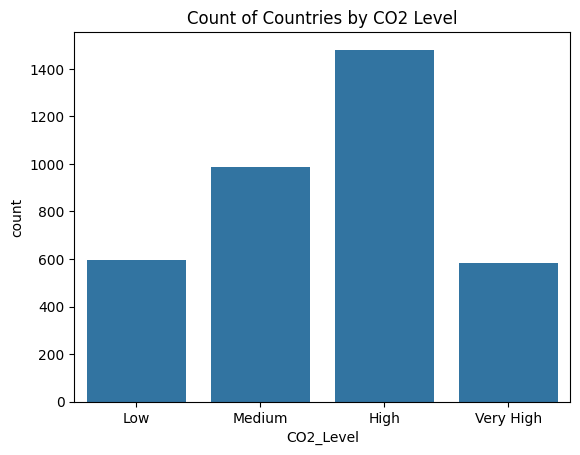

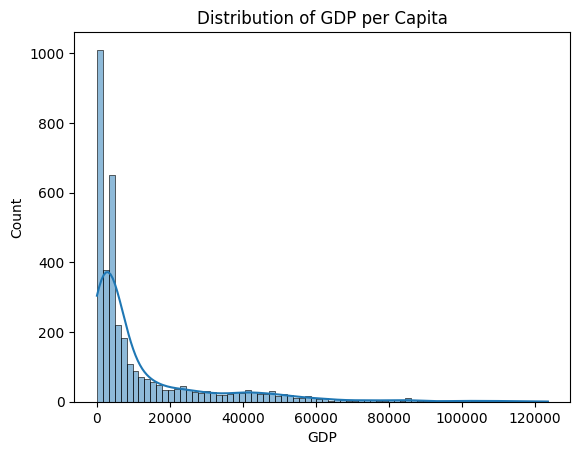

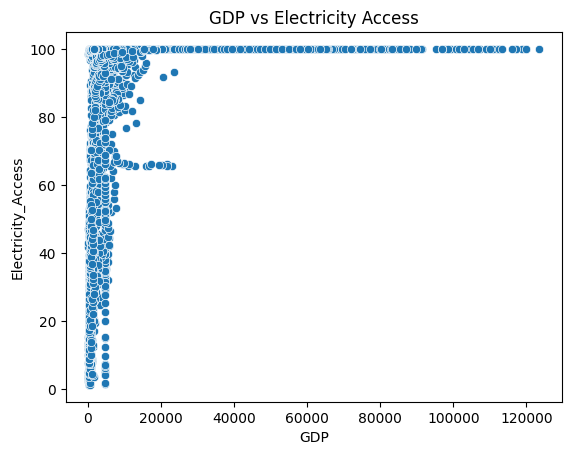

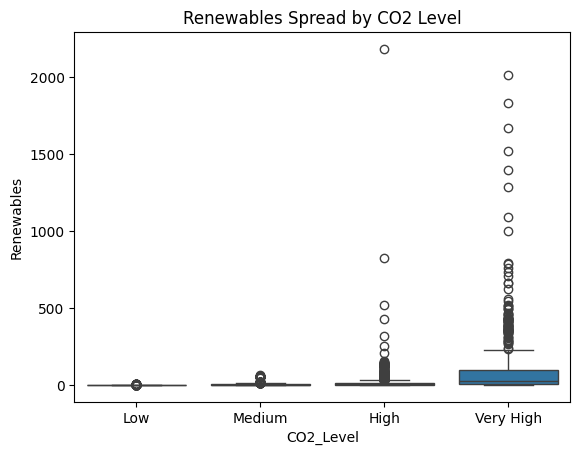


Saved as sustainable_energy_simple_cleaned.csv


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder


df = pd.read_csv(r'global-data-on-sustainable-energy (1).csv')

print("Original Data")
print(df.head())



df = df[[
    'Entity',
    'Year',
    'Access to electricity (% of population)',
    'gdp_per_capita',
    'Value_co2_emissions_kt_by_country',
    'Electricity from renewables (TWh)'
]]

df.columns = ['Country', 'Year', 'Electricity_Access', 'GDP', 'CO2', 'Renewables']

print("\nSelected columns")
print(df.head())

# Check null values


print("\nNull values before cleaning")
print(df.isnull().sum())


# Handle null values
# fillna() replaces missing values with something we choose
# here we use median() -> the middle value of the column, good for numbers
# because it isn't affected much by very high or very low values


df['Electricity_Access'] = df['Electricity_Access'].fillna(df['Electricity_Access'].median())
df['GDP'] = df['GDP'].fillna(df['GDP'].median())
df['CO2'] = df['CO2'].fillna(df['CO2'].median())
df['Renewables'] = df['Renewables'].fillna(df['Renewables'].median())

print("\nNull values after cleaning")
print(df.isnull().sum())


# Create a grade-like category from CO2 emissions

# High CO2 = more pollution, Low CO2 = less pollution


def co2_level(value):
    if value >= 100000:
        return 'Very High'
    elif value >= 10000:
        return 'High'
    elif value >= 1000:
        return 'Medium'
    else:
        return 'Low'

df['CO2_Level'] = df['CO2'].apply(co2_level)

print("\nData with CO2_Level column")
print(df.head())



df_copy = df.copy()


print("\ncategorical")

# Country has too many unique values (176 countries) so One-Hot Encoding
# is not used on it (it would create 176 new columns).
# We use it on Year instead is not ideal either since Year has many values.
# Best example of a small-category column here is CO2_Level (only 4 values).

df_copy = pd.get_dummies(
    df_copy,
    columns=['CO2_Level'],
    dtype=int
)



# Country doesn't have a natural order, so Ordinal Encoding isn't right
# for it. CO2_Level DOES have a natural order (Low < Medium < High < Very
# High), so we use Ordinal Encoding on that instead, on the original df
# (before it got one-hot encoded in df_copy)

ordinal = OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']])
df[['CO2_Level_Ordinal']] = ordinal.fit_transform(df[['CO2_Level']])

print("\nordinal")
print(df[['CO2_Level', 'CO2_Level_Ordinal']].head())


# Standard Scaling
# makes all number columns comparable (same scale)
# GDP can be in thousands, Electricity_Access is 0-100 -- scaling fixes that


scaler = StandardScaler()

num_cols = ['Electricity_Access', 'GDP', 'CO2', 'Renewables']

df_copy[num_cols] = scaler.fit_transform(df_copy[num_cols])



print("\nProcessed Data")
print(df_copy.head())



# countplot -> shows how many rows fall into each category
plt.figure()
sns.countplot(data=df, x='CO2_Level')
plt.title('Count of Countries by CO2 Level')
plt.savefig('co2_level_count.png')
plt.show()

# histplot -> shows the distribution/spread of a number column
plt.figure()
sns.histplot(df['GDP'], kde=True)
plt.title('Distribution of GDP per Capita')
plt.savefig('gdp_distribution.png')
plt.show()

# scatterplot -> shows relationship between two number columns
plt.figure()
sns.scatterplot(data=df, x='GDP', y='Electricity_Access')
plt.title('GDP vs Electricity Access')
plt.savefig('gdp_vs_electricity.png')
plt.show()

# boxplot -> shows spread and outliers of a number column across categories
plt.figure()
sns.boxplot(data=df, x='CO2_Level', y='Renewables')
plt.title('Renewables Spread by CO2 Level')
plt.savefig('renewables_by_co2_level.png')
plt.show()


df_copy.to_csv('sustainable_energy_simple_cleaned.csv', index=False)
print("\nSaved as sustainable_energy_simple_cleaned.csv")